# Figure: Zero-shot vs ICL (zs_vs_icl.pdf)

Bar chart comparing EDC+ zero-shot vs in-context learning, with delta annotations.
Two subplots: Completeness (C) and G-BERTScore-R (G-R).

## Data source

This figure requires both ICL and ZS EDC+ models (4 models total). Two loading modes:

1. **New pipeline pkl** (default): loads from the 13-model `wiki_eval_result.pkl` which
   includes both ICL and ZS models. Uses `USE_OLD_PIPELINE = False`.

2. **Old pipeline pkls** (fallback): loads from separate per-part pkl files under
   `s14b_load_dataset_opt_preds_v13/`. Set `USE_OLD_PIPELINE = True`. Uses legacy scoring.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), 'src'))
sys.path.insert(0, os.path.join(os.path.abspath('../../..'), 'src'))

from stats.evaluation.load_results import (
    load_results,
    metrics_to_report_cie,
    model_name_to_latex,
    make_agg_and_agg_open,
    make_agg_all,
    alias_label,
)

In [2]:
# =====================================================================
# OPTION A: Old pipeline cached pkls (legacy scoring — reproduces ICML submission exactly)
# =====================================================================
# To use: set USE_OLD_PIPELINE = True
OLD_PIPELINE_CACHE_DIR = '/path/to/data/wikipedia-processing/src/stats/cache_stats/'
OLD_PIPELINE_CONFIG_PATH = '../../experiments/s14_experiments_stats_v13_ipynb/20260122_all_stats_for_tiny_slurm/config.json'
# USE_OLD_PIPELINE = True

# =====================================================================
# OPTION B: New pipeline pkl (13 models including ZS)
# =====================================================================
# To use: set USE_OLD_PIPELINE = False and uncomment one PKL_PATH below.
USE_OLD_PIPELINE = False

# --- Legacy scoring + KG snapshots (reproduces paper values, new pipeline):
PKL_PATH = '/path/to/storage/emerge/output/experiments/s0x_evaluate_predictions/20260324_all_models_with_zs_legacy_with_kg/wiki_eval_result.pkl'
# --- Fixed scoring + KG snapshots (score_empty_predictions_as_zero=true):
# PKL_PATH = '/path/to/storage/emerge/output/experiments/s0x_evaluate_predictions/20260324_all_models_with_zs_fixed_with_kg/wiki_eval_result.pkl'

# Where to save the figure (set to None to skip saving)
SAVE_DIR = '/path/to/storage/emerge/output/figures/'

# Assessor config — naming differs between pipelines:
# Old pipeline: WITH prompt_type suffix (e.g. _triple_assertion)
# New pipeline: WITHOUT suffix (e.g. Meta-Llama-3.1-405B_prompt_v1)
assessor_by_prompt_type_old = {
    'triple_assertion': 'Meta-Llama-3.1-405B_prompt_v1_triple_assertion',
    'triple_deprecation': 'Meta-Llama-3.1-405B_prompt_v1_triple_deprecation'
}
assessor_by_prompt_type_new = {
    'triple_assertion': 'Meta-Llama-3.1-405B_prompt_v1',
    'triple_deprecation': 'Meta-Llama-3.1-405B_prompt_v1'
}

In [3]:
import hashlib
import json as json_mod

# Models needed for this figure (ICL + ZS)
zs_icl_models = {
    "edc-plus-open-ai/gpt-5.1/non-canonicalized",
    "edc-plus-azure_ai/Mistral-Large-2411",
    "edc-plus-zshot-open_ai/GPT-5_1",
    "edc-plus-zshot-azure_ai/Mistral-Large-2411",
}

if USE_OLD_PIPELINE:
    # Compute cache key (same logic as s14_load_results_v13.py _cache_key/_assessor_cache_tag)
    cache_key = hashlib.sha256(OLD_PIPELINE_CONFIG_PATH.encode("utf-8")).hexdigest()[:16]
    canonical = json_mod.dumps(assessor_by_prompt_type_old, sort_keys=True, separators=(",", ":"))
    assessor_tag = f"assessor_{hashlib.sha256(canonical.encode('utf-8')).hexdigest()[:12]}"
    prefix = f"{cache_key}_{assessor_tag}"

    df_wiki_metrics_cie = pd.read_pickle(os.path.join(OLD_PIPELINE_CACHE_DIR, f"{prefix}_df_wiki_metrics_cie.pkl"))
    df_metrics_open_ie = pd.read_pickle(os.path.join(OLD_PIPELINE_CACHE_DIR, f"{prefix}_df_metrics_open_ie.pkl"))

    # Filter to ZS/ICL models only
    df_wiki_metrics_cie = df_wiki_metrics_cie[df_wiki_metrics_cie['model'].isin(zs_icl_models)]
    df_metrics_open_ie = df_metrics_open_ie[df_metrics_open_ie['model'].isin(zs_icl_models)]

    print(f'Loaded from old pipeline cache: {OLD_PIPELINE_CACHE_DIR}')
    print(f'Cache prefix: {prefix}')
else:
    # Load from new pipeline WikiEvalResult pkl
    (df_wiki_metrics_cie, df_metrics_open_ie, df_preds_gt_cie,
     df_preds_open_ie, df_instances, df_additional_stats) = load_results(
        pkl_path=PKL_PATH,
        assessor_by_prompt_type=assessor_by_prompt_type_new,
        filter_models=zs_icl_models,
    )

print(f'df_wiki_metrics_cie.shape: {df_wiki_metrics_cie.shape}')
print(f'Models loaded: {sorted(df_wiki_metrics_cie.model.unique().tolist())}')

# Sanity check
missing = zs_icl_models - set(df_wiki_metrics_cie.model.unique())
if missing:
    print(f'WARNING: Missing models: {missing}')
    print('This figure requires both ICL and ZS models.')

df_wiki_metrics_cie.shape: (1605711, 10)
df_wiki_metrics_cie_filtered.shape: (1554711, 10)
df_preds_gt_cie.shape: (36245, 24)
df_preds_gt_cie_filtered.shape: (23122, 25)


df_wiki_metrics_cie.shape: (1642280, 12)
Models loaded: ['edc-plus-azure_ai/Mistral-Large-2411', 'edc-plus-open-ai/gpt-5.1/non-canonicalized', 'edc-plus-zshot-azure_ai/Mistral-Large-2411', 'edc-plus-zshot-open_ai/GPT-5_1']


In [4]:
# Aggregate
spec = pd.DataFrame(metrics_to_report_cie)
agg, agg_open = make_agg_and_agg_open(
    df_wiki_metrics_cie=df_wiki_metrics_cie,
    df_metrics_open_ie=df_metrics_open_ie,
    spec=spec,
)
agg_all = make_agg_all(agg, agg_open)

No overlapping (metric, evaluator_model, model) between agg and agg_open.
sanity check, all have to be in 1: 1    80
Name: count, dtype: int64


In [5]:
# --- Prepare data for plotting ---

model_name_to_setting = {
    "edc-plus-open-ai/gpt-5.1/non-canonicalized": "ICL",
    "edc-plus-zshot-open_ai/GPT-5_1": "ZS",
    "edc-plus-azure_ai/Mistral-Large-2411": "ICL",
    "edc-plus-zshot-azure_ai/Mistral-Large-2411": "ZS",
}

model_name_to_llm = {
    "edc-plus-open-ai/gpt-5.1/non-canonicalized": "GPT 5.1",
    "edc-plus-azure_ai/Mistral-Large-2411": "Mistral-Large",
    "edc-plus-zshot-open_ai/GPT-5_1": "GPT 5.1",
    "edc-plus-zshot-azure_ai/Mistral-Large-2411": "Mistral-Large",
}

show_aliases = ["C", "G-R"]
inv_alias_label = {v: k for k, v in alias_label.items()}
show_raw_aliases = {inv_alias_label.get(a, a) for a in show_aliases}

agg_show = agg_all[agg_all["model"].isin(zs_icl_models)].copy()
agg_show = agg_show[agg_show["group"] != "LLM-as-a-judge"].copy()
agg_show = agg_show[agg_show["alias"].isin(show_raw_aliases)].copy()
agg_show["alias_label"] = agg_show["alias"].map(alias_label)
agg_show["setting"] = agg_show["model"].map(model_name_to_setting)
agg_show["model_alias"] = "EDC+"
agg_show["llm"] = agg_show["model"].map(model_name_to_llm)

df_to_plot = agg_show[["tkgu_type", "model_alias", "score_scaled",
                        "alias_label", "setting", "llm"]].copy()
df_to_plot = df_to_plot.rename(columns={
    "model_alias": "model",
    "score_scaled": "score",
    "alias_label": "metric",
})

print(df_to_plot.head(10))

    tkgu_type model      score metric setting            llm
0   d-triples  EDC+  45.342707      C     ICL  Mistral-Large
3   d-triples  EDC+  75.522990    G-R     ICL  Mistral-Large
4   d-triples  EDC+  50.897666      C     ICL        GPT 5.1
7   d-triples  EDC+  78.603159    G-R     ICL        GPT 5.1
8   d-triples  EDC+  19.594595      C      ZS  Mistral-Large
11  d-triples  EDC+  61.466190    G-R      ZS  Mistral-Large
12  d-triples  EDC+  32.000000      C      ZS        GPT 5.1
15  d-triples  EDC+  67.502115    G-R      ZS        GPT 5.1
16  e-triples  EDC+  30.717789      C     ICL  Mistral-Large
19  e-triples  EDC+  72.032690    G-R     ICL  Mistral-Large


In [6]:
def plot_zs_icl_bars_with_delta_twometrics(
    df,
    llms=("GPT 5.1",),
    metrics=("C", "G-R"),
    metric_to_ylabel=None,
    tkgu_type_to_label=None,
    preferred_order_labels=None,
    figsize=(8.2, 3.6),
    axis_label_size=13,
    tick_label_size=12,
    legend_fontsize=12,
    delta_fontsize=12,
    bar_width=0.42,
    connector_lw=1.6,
    subplot_wspace=0.18,
    y_top_margin_frac=0.08,
):
    """
    ICML-style hybrid plot:
    - bars for ZS vs ICL
    - vertical connector (ZS -> ICL)
    - delta annotation (ICL - ZS)
    - two subplots: one per metric
    """
    icl_fill = "#c9dced"
    icl_edge = "#4f7fa8"
    zs_fill  = "#e2e2e2"
    zs_edge  = "#6f6f6f"

    if metric_to_ylabel is None:
        metric_to_ylabel = {
            "C": "Completeness",
            "G-R": "G-BERTScore-R",
        }

    d = df.copy()
    d = d[d["llm"].isin(llms)]

    if tkgu_type_to_label is not None:
        d["_tkgu_label"] = d["tkgu_type"].map(tkgu_type_to_label)
    else:
        d["_tkgu_label"] = d["tkgu_type"]

    if preferred_order_labels is not None:
        d["_tkgu_label"] = pd.Categorical(
            d["_tkgu_label"], preferred_order_labels, ordered=True)
        d = d.sort_values("_tkgu_label")

    fig, axes = plt.subplots(1, len(metrics), figsize=figsize, sharey=False)
    if len(metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        dm = d[d["metric"] == metric]
        piv = (
            dm.pivot_table(
                index="_tkgu_label", columns="setting",
                values="score", aggfunc="mean")
            .dropna()
        )

        x = np.arange(len(piv.index))
        width = bar_width

        ax.bar(x - width / 2, piv["ICL"], width, label="In-context",
               color=icl_fill, edgecolor=icl_edge, linewidth=1.2, zorder=2)
        ax.bar(x + width / 2, piv["ZS"], width, label="Zero-shot",
               color=zs_fill, edgecolor=zs_edge, linewidth=1.2, zorder=2)

        for i, idx in enumerate(piv.index):
            zs = piv.loc[idx, "ZS"]
            icl = piv.loc[idx, "ICL"]
            ax.plot([x[i], x[i]], [zs, icl], color="black",
                    linewidth=connector_lw, alpha=0.75, zorder=3)
            ax.text(x[i], max(zs, icl) + 0.8, f"{icl - zs:+.1f}",
                    ha="center", va="bottom", fontsize=delta_fontsize)

        ymin, ymax = ax.get_ylim()
        yrange = ymax - ymin
        ax.set_ylim(ymin, ymax + y_top_margin_frac * yrange)

        ax.set_xticks(x)
        ax.set_xticklabels(piv.index.tolist(), fontsize=tick_label_size)
        ax.set_ylabel(metric_to_ylabel.get(metric, metric), fontsize=axis_label_size)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
        ax.tick_params(axis="y", labelsize=tick_label_size)
        ax.yaxis.grid(True, color="gray", linestyle="--", linewidth=0.7, alpha=0.45)
        ax.set_axisbelow(True)

        if ax is axes[0]:
            ax.legend(frameon=False, fontsize=legend_fontsize, loc="upper left")

    plt.subplots_adjust(wspace=subplot_wspace)
    plt.tight_layout(pad=0.6, rect=(0, 0, 1, 1))
    return fig

/tmp/ipykernel_2011427/1139782771.py:56: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  dm.pivot_table(
/tmp/ipykernel_2011427/1139782771.py:56: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  dm.pivot_table(


Saved to /path/to/storage/emerge/output/figures/


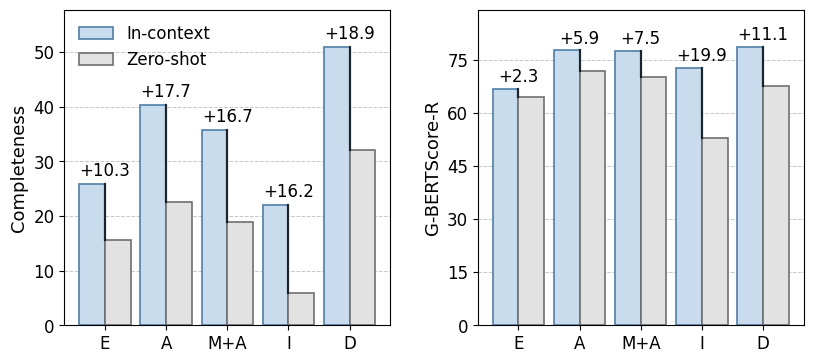

In [7]:
tkgu_type_to_label = {
    "x-triples": "E",
    "ee-kg-triples": "I",
    "e-triples": "A",
    "ee-triples": "M+A",
    "d-triples": "D",
}
preferred_order_labels = ["E", "A", "M+A", "I", "D"]

fig = plot_zs_icl_bars_with_delta_twometrics(
    df_to_plot,
    llms=("GPT 5.1",),
    metrics=("C", "G-R"),
    tkgu_type_to_label=tkgu_type_to_label,
    preferred_order_labels=preferred_order_labels,
    subplot_wspace=3.0,
)

if SAVE_DIR is not None:
    os.makedirs(SAVE_DIR, exist_ok=True)
    fig.savefig(os.path.join(SAVE_DIR, "zs_vs_icl.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(SAVE_DIR, "zs_vs_icl.png"), bbox_inches="tight", dpi=300)
    print(f"Saved to {SAVE_DIR}")

plt.show()